In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def TDT(T):
    b = T[0]+T[2]+2*T[3]; c = T[1]+T[2]+2*T[4]
    if b+c == 0:
        return 0
    else:
        return ((b-c)**2)/(b+c)

In [3]:
def EDOLS_TDT(x,n,m): #Enhanced DOLS
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
    
    #Step 1
    c = np.zeros((m,n,2))
    for i in range(m):
        T = TG[i]; X = TDT(T)
        for j in range(n):
            if x[j][i] == 0:
                Y = TDT([T[0]-1, T[1]+1, T[2], T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 1:
                Y = TDT([T[0]+1, T[1]-1, T[2], T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 2:
                Y = TDT([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]-1, T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]-1, T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 3:
                Y = TDT([T[0]+1, T[1], T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]+1, T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]-1, T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 4:
                Y = TDT([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]+1, T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3], T[4]-1, T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if T[5] >= 1:
                Y = TDT([T[0]+1, T[1], T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]+1, T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3], T[4]+1, T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
    
    #Step 2
    LSS = np.zeros(int(2**m)); LS_SIGN = np.zeros(m)
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = c[0][j][0]; LSJ[0][1] = c[0][j][1]
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + c[i][j][0]
                LSJ[i][2*k+1] = LSJ[i-1][k] + c[i][j][1]
        for i in range(int(2**m)):
            if LSS[i] < LSJ[m-1][i]:
                LSS[i] = LSJ[m-1][i]
                for l in range(m):
                    LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    LS = 0
    for i in range(int(2**m)):
        if LS < LSS[i]:
            LS = LSS[i]
            for l in range(m):
                LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    #print(LS_SIGN)
        
    #Step 3
    EDOLS = np.zeros((m,2)) #\hat{LS}^{i+-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                EDOLS[j][0] = max(EDOLS[j][0], LSS[i])
            else:
                EDOLS[j][1] = max(EDOLS[j][1], LSS[i])
    #print(EDOLS[:,0], EDOLS[:,1])
    
    #Step 4
    for i in range(m):
        if LS_SIGN[i] == 0:
            d = 1
        else:
            d = 0
        EDOLS[i][d] = 0
        for j in range(n):
            for s in range(int(2**m)):
                if int(s/(2**(m-1-i)))%2 == d:
                    t = 0
                    for l in range(m):
                        if l != i and EDOLS[l][int(s/(2**(m-1-l)))%2] != 0:
                            t += c[l][j][int(s/(2**(m-1-l)))%2]/EDOLS[l][int(s/(2**(m-1-l)))%2]
                    if t != 1:
                        EDOLS[i][d] = max(EDOLS[i][d], c[i][j][d]/(1-t))
    #print(EDOLS)
    return EDOLS[:,0], EDOLS[:,1]

In [4]:
def DOLS_TDT(x,n,m):
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
    
    #Step 1
    MCP = np.zeros((m,6)); MCN = np.zeros((m,6)) #MaxChange
    for i in range(m):
        T = TG[i]
        X = TDT(T); MCP[i] = np.zeros(6); MCN[i] = np.zeros(6)
        if T[0] >= 1:
            Y = TDT([T[0]-1, T[1]+1, T[2], T[3], T[4], T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = TDT([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = TDT([T[0]-1, T[1], T[2], T[3]+1, T[4], T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = TDT([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
            Y = TDT([T[0]-1, T[1], T[2], T[3], T[4], T[5]+1])
            MCP[i][0] = max(MCP[i][0], Y-X); MCN[i][0] = max(MCN[i][0], X-Y)
        if T[1] >= 1:
            Y = TDT([T[0]+1, T[1]-1, T[2], T[3], T[4], T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = TDT([T[0], T[1]-1, T[2]+1, T[3], T[4], T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = TDT([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = TDT([T[0], T[1]-1, T[2], T[3], T[4]+1, T[5]])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
            Y = TDT([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
            MCP[i][1] = max(MCP[i][1], Y-X); MCN[i][1] = max(MCN[i][1], X-Y)
        if T[2] >= 1:
            Y = TDT([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = TDT([T[0], T[1]+1, T[2]-1, T[3], T[4], T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = TDT([T[0], T[1], T[2]-1, T[3]+1, T[4], T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = TDT([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
            Y = TDT([T[0], T[1], T[2]-1, T[3], T[4], T[5]+1])
            MCP[i][2] = max(MCP[i][2], Y-X); MCN[i][2] = max(MCN[i][2], X-Y)
        if T[3] >= 1:
            Y = TDT([T[0]+1, T[1], T[2], T[3]-1, T[4], T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = TDT([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = TDT([T[0], T[1], T[2]+1, T[3]-1, T[4], T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = TDT([T[0], T[1], T[2], T[3]-1, T[4]+1, T[5]])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
            Y = TDT([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
            MCP[i][3] = max(MCP[i][3], Y-X); MCN[i][3] = max(MCN[i][3], X-Y)
        if T[4] >= 1:
            Y = TDT([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = TDT([T[0], T[1]+1, T[2], T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = TDT([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = TDT([T[0], T[1], T[2], T[3]+1, T[4]-1, T[5]])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
            Y = TDT([T[0], T[1], T[2], T[3], T[4]-1, T[5]+1])
            MCP[i][4] = max(MCP[i][4], Y-X); MCN[i][4] = max(MCN[i][4], X-Y)
        if T[5] >= 1:
            Y = TDT([T[0]+1, T[1], T[2], T[3], T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = TDT([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = TDT([T[0], T[1], T[2]+1, T[3], T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = TDT([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
            Y = TDT([T[0], T[1], T[2], T[3], T[4]+1, T[5]-1])
            MCP[i][5] = max(MCP[i][5], Y-X); MCN[i][5] = max(MCN[i][5], X-Y)
    #print(MCP, MCN)
    
    #Step 2
    LSS = np.zeros(int(2**m))
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = MCP[0][int(x[j][0])]; LSJ[0][1] = MCN[0][int(x[j][0])]
        #print(LSJ[0],LSJ[1])
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + MCP[i][int(x[j][i])]
                LSJ[i][2*k+1] = LSJ[i-1][k] + MCN[i][int(x[j][i])]
        #print(LSJ)
        for i in range(int(2**m)):
            LSS[i] = max(LSS[i],LSJ[m-1][i])    
        #print(LSS)
        
    #Step 3
    DOLSP = np.zeros(m) #LS^{i+}
    DOLSN = np.zeros(m) #LS^{i-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                DOLSP[j] = max(DOLSP[j], LSS[i])
            else:
                DOLSN[j] = max(DOLSN[j], LSS[i])
    
    return DOLSP, DOLSN

In [5]:
def DOSS_TDT_test(n,m):
    x = np.ones((n,m))
    while(1):
        f = 0
        for j in range(m):
            x[:,j] = np.ones(n); T = np.zeros(6)
            for i in range(n):
                r = random.random()
                if r < 1/4:
                    x[i][j] = 0; T[0] += 1
                elif r < 1/4+1/n:
                    x[i][j] = 1; T[1] += 1
                elif r < 1/4+2/n:
                    x[i][j] = 2; T[2] += 1
                elif r < 5/12+2/n:
                    x[i][j] = 3; T[3] += 1
                elif r < 5/12+3/n:
                    x[i][j] = 4; T[4] += 1
                else:
                    x[i][j] = 5; T[5] += 1
            if TDT(T) == 0 and TDT(T) == 2*n:
                f = 1
        EDOLSP, EDOLSN = EDOLS_TDT(x,n,m)
        for i in range(m):
            if EDOLSP[i] == 0 or EDOLSN[i] == 0:
                f = 1
            elif (EDOLSP[i]/EDOLSN[i])*24 > math.exp(16/4) or (EDOLSN[i]/EDOLSP[i])*24 > math.exp(16/4):
                f = 1
        if f == 0:
            break
    return x

In [6]:
def h3(z,l):
    return (3*np.sqrt(3)*(l**(2/3)))/(4*math.pi*(math.fabs(z)**3+l))

def h4(z,l):
    return (np.sqrt(2)*(l**(3/4)))/(math.pi*(z**4+l))

def cdf(x,h,l):
    g = lambda z: h(z,l)
    return integrate.quad(g,-oo,x)

def noise(h,l,d): # using inverse transform sampling
    r = np.random.rand()
    q = 1000; z = 10
    for i in range(-50,50):
        if math.fabs(r - cdf(i/5,h,l)[0]) > q:
            z = (i-1)/5
            break
        else:
            q = min(q, math.fabs(r - cdf(i/5,h,l)[0]))
    if d == 0:
        return math.fabs(z)
    elif d == 1:
        return -math.fabs(z)
    
def alpha(k,l,m,ei): #epsilon = ei*m
    return ((l**(1/k))*(ei*m))/(2*((k-1)**((k-1)/k)))

In [7]:
def accuracy(n,m,EDOSSP,EDOSSN,UEDOSSP,UEDOSSN):
    acc = np.zeros((6,3))
    k = 3; l = 3
    SS = np.zeros(20)
    ei = [25+10*i for i in range(6)]
    
    for j in range(20):
        SS[j] = max(max(EDOSSP[j]), max(EDOSSN[j]))
        for i in range(6):
            for t in range(m):
                if random.random()<0.5:
                    z = noise(h3,l,0)
                    acc[i][0] += math.fabs((EDOSSP[j][t]/alpha(k,l,m,ei[i]))*z)
                    acc[i][2] += math.fabs((SS[j]/alpha(k,l,m,ei[i]))*z)
                else:
                    z = noise(h3,l,1)
                    acc[i][0] += math.fabs((EDOSSN[j][t]/alpha(k,l,m,ei[i]))*z)
                    acc[i][2] += math.fabs((SS[j]/alpha(k,l,m,ei[i]))*z)
            for t in range(m):
                if random.random()<UEDOSSN[j][t]/(UEDOSSP[j][t]+UEDOSSN[j][t]):
                    z = noise(h3,l,0)
                    acc[i][1] += math.fabs((UEDOSSP[j][t]/alpha(k,l,m,(ei[i]*(2/3))))*z)
                else:
                    z = noise(h3,l,1)
                    acc[i][1] += math.fabs((UEDOSSN[j][t]/alpha(k,l,m,(ei[i]*(2/3))))*z)
    return acc/(m*20)

[[0.72684664 0.6251825  0.93670246]
 [0.43414788 0.57027114 0.58981016]
 [0.39696177 0.64191422 0.55121477]
 [0.34895301 0.31707707 0.4465433 ]
 [0.29541694 0.27509626 0.3916526 ]
 [0.26684855 0.26498773 0.34487187]]
[[0.60756048 1.11359478 0.80288782]
 [0.44570357 0.65397028 0.59214143]
 [0.34634852 0.56189997 0.51495064]
 [0.38265801 0.48339815 0.4420927 ]
 [0.3229251  0.35464731 0.40922675]
 [0.30696281 0.30766037 0.42211447]]
[[0.65999215 1.16149473 0.8746908 ]
 [0.47455927 0.62118371 0.7017109 ]
 [0.3601302  0.47337407 0.46236765]
 [0.29527368 0.37079642 0.36791608]
 [0.2560828  0.33976662 0.3138242 ]
 [0.25333756 0.30246534 0.33943225]]
[[0.50863181 0.81059232 0.76045879]
 [0.48287803 0.62257367 0.61778535]
 [0.31653498 0.48972228 0.41159787]
 [0.2560828  0.49763846 0.40797146]
 [0.24760729 0.42796364 0.33390895]
 [0.18582757 0.26530178 0.26654135]]
[[0.63679355 0.74331225 0.81920668]
 [0.39962754 0.82456985 0.48956575]
 [0.48596216 0.49150777 0.57116004]
 [0.2595595  0.30774362 

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


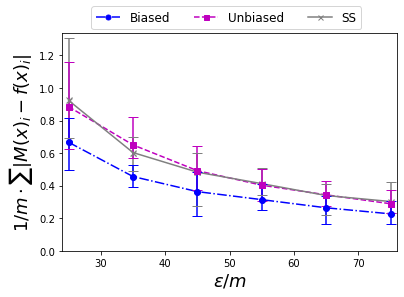

In [8]:
n = 150; m = 2

acc = np.zeros((6,3))
max_acc = np.zeros((6,3)); min_acc = np.ones((6,3))
sum_acc = np.zeros((6,3))


#x = DOSS_TDT_test(n,m)
x = np.ones((n,m))
for j in range(m):
    for i in range(n):
        if i < 10:
            x[i][j] = 2
        else:
            x[i][j] = 3

EDOSSP = np.zeros((20,m)); EDOSSN = np.zeros((20,m))
UEDOSSP = np.zeros((20,m)); UEDOSSN = np.zeros((20,m))
for i in range(20):
    EDOSSP[i], EDOSSN[i] = EDOLS_TDT(x,n,m)
    UEDOSSP[i] = EDOSSP[i]; UEDOSSN[i] = EDOSSN[i]

jj = 10
for j in range(jj):
    acc = accuracy(n,m,EDOSSP,EDOSSN,UEDOSSP,UEDOSSN)
    for i in range(6):
        for k in range(3):
            max_acc[i][k] = max(max_acc[i][k], acc[i][k])
            min_acc[i][k] = min(min_acc[i][k], acc[i][k])
            sum_acc[i][k] += acc[i][k]
    print(acc)
acc = sum_acc/jj

y_err = np.zeros((2,6,3))
for k in range(3):
    y_err[0,:,k] = acc[:,k] - min_acc[:,k]
    y_err[1,:,k] = max_acc[:,k] - acc[:,k]

ei = [25+10*i for i in range(6)]

print(acc)
fig = plt.figure()
plt.ylim(0, max(max_acc[i][j] for i in range(6) for j in range(3))+0.03)
plt.xlim(24, 76)
plt.plot(ei, acc[:,0], marker="o", markersize=5, color = "blue", linestyle = "dashdot", label = "Biased")
plt.plot(ei, acc[:,1], marker="s", markersize=5, color = "m", linestyle = "--", label = "Unbiased")
plt.plot(ei, acc[:,2], marker="x", markersize=5, color = "gray", linestyle = "-", label = "SS")
plt.errorbar(ei, acc[:,2], yerr = y_err[:,:,2], capsize=5, fmt='x', ecolor='gray', markeredgecolor = "gray", color='gray')
plt.errorbar(ei, acc[:,1], yerr = y_err[:,:,1], capsize=5, fmt='s', ecolor='m', markeredgecolor = "m", color='m')
plt.errorbar(ei, acc[:,0], yerr = y_err[:,:,0], capsize=5, fmt='o', ecolor='blue', markeredgecolor = "blue", color='blue')
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=3, fontsize=12)
plt.xlabel("$\epsilon/m$", fontsize = 18)
plt.ylabel("$1/m \cdot \sum |M(x)_i - f(x)_i|$", fontsize = 18)
fig.savefig("Accuracy_TDT_Unbiased_m=2_particularX.png")
fig.savefig("figs/Accuracy_TDT_Unbiased_m=2_particularX.eps", bbox_inches="tight", pad_inches=0.05)